In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

lap_df = pd.read_csv("../data/processed/lap_times_processed.csv")

lap_df["lap_time_s"] = pd.to_numeric(lap_df["lap_time_s"], errors="coerce")
lap_df = lap_df.dropna(subset=["lap_time_s"])

lap_df.head()

,raceId,driverId,lap,position,lap_time_str,lap_time_ms,lap_time_s
0,841,20,1,1,1:38.109,98109,98.109
1,841,20,2,1,1:33.006,93006,93.006
2,841,20,3,1,1:32.713,92713,92.713
3,841,20,4,1,1:32.803,92803,92.803
4,841,20,5,1,1:32.342,92342,92.342


In [13]:
race_id = lap_df["raceId"].iloc[0]
driver_id = lap_df["driverId"].iloc[0]

print("Testing race:", race_id)
print("Testing driver:", driver_id)

Testing race: 841
Testing driver: 20


In [14]:
data = lap_df[
    (lap_df["raceId"] == race_id) &
    (lap_df["driverId"] == driver_id)
].copy()

data = data.sort_values("lap").reset_index(drop=True)

data.head()

,raceId,driverId,lap,position,lap_time_str,lap_time_ms,lap_time_s
0,841,20,1,1,1:38.109,98109,98.109
1,841,20,2,1,1:33.006,93006,93.006
2,841,20,3,1,1:32.713,92713,92.713
3,841,20,4,1,1:32.803,92803,92.803
4,841,20,5,1,1:32.342,92342,92.342


In [15]:
data["lap_diff"] = data["lap_time_s"].diff()

pit_threshold = 12  # seconds increase = pit stop

data["pit_stop"] = data["lap_diff"] > pit_threshold

pit_laps = data[data["pit_stop"]]["lap"].tolist()

print("Detected pit laps:", pit_laps)

Detected pit laps: [14, 36]


In [16]:
data["stint"] = 1
stint_counter = 1

for i in range(len(data)):
    data.loc[i, "stint"] = stint_counter
    
    if data.loc[i, "pit_stop"]:
        stint_counter += 1

data[["lap", "stint"]].head(25)

,lap,stint
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


In [17]:
stint_results = []

for stint in data["stint"].unique():
    
    stint_data = data[data["stint"] == stint].copy()
    
    # Skip very short stints
    if len(stint_data) < 5:
        continue
  
    q_low = stint_data["lap_time_s"].quantile(0.05)
    q_high = stint_data["lap_time_s"].quantile(0.95)
    
    stint_data = stint_data[
        (stint_data["lap_time_s"] > q_low) &
        (stint_data["lap_time_s"] < q_high)
    ]
    
    if len(stint_data) < 5:
        continue
    
    X = stint_data[["lap"]]
    y = stint_data["lap_time_s"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    slope = model.coef_[0]
    r2 = model.score(X, y)
    std_dev = y.std()
    
    stint_results.append({
        "stint": stint,
        "laps": len(stint_data),
        "degradation_slope_sec_per_lap": slope,
        "r2_fit": r2,
        "consistency_index": 1 / std_dev
    })

stint_results_df = pd.DataFrame(stint_results)

stint_results_df

,stint,laps,degradation_slope_sec_per_lap,r2_fit,consistency_index
0,1,12,-0.157612,0.164990,0.641259
1,2,18,0.025877,0.123575,2.326228
2,3,18,0.034510,0.266107,2.541654


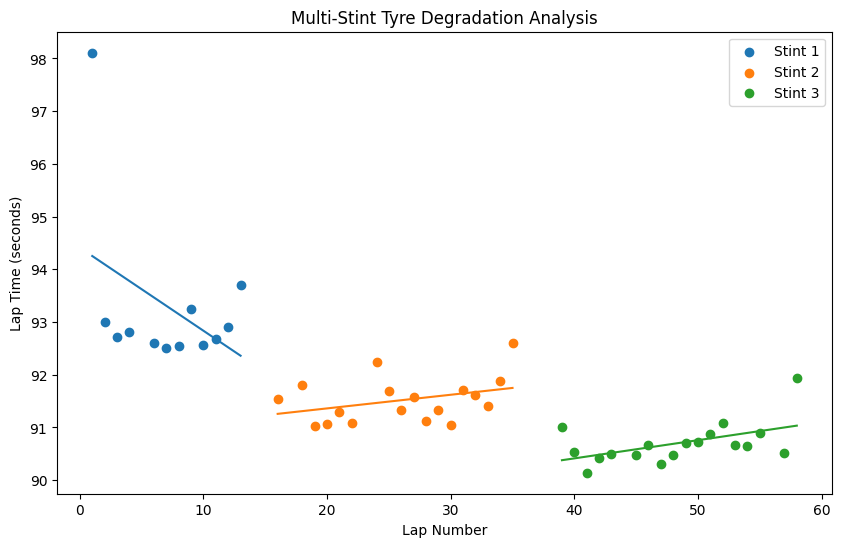

In [18]:
plt.figure(figsize=(10,6))

for stint in data["stint"].unique():
    
    stint_data = data[data["stint"] == stint]
    
    if len(stint_data) < 5:
        continue
    
    q_low = stint_data["lap_time_s"].quantile(0.05)
    q_high = stint_data["lap_time_s"].quantile(0.95)
    
    stint_data = stint_data[
        (stint_data["lap_time_s"] > q_low) &
        (stint_data["lap_time_s"] < q_high)
    ]
    
    if len(stint_data) < 5:
        continue

    X = stint_data[["lap"]]
    y = stint_data["lap_time_s"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    plt.scatter(stint_data["lap"], y, label=f"Stint {stint}")
    plt.plot(stint_data["lap"], model.predict(X))

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Multi-Stint Tyre Degradation Analysis")
plt.legend()
plt.show()